<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/03_3_Hernandez_Alvaro_TranferenciaAprendizaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio de transferencia de aprendizaje**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 1 de marzo de 2026




# **Indicaciones**

El archivo compartido representa un ejemplo de aplicación de transferencia de aprendizaje utilizando datos de imágenes histopatológicas. En el ejercicio que realizamos en clase trabajamos con imágenes de colon; sin embargo, para este problema deberán trabajar con imágenes histopatológicas de pulmón.<br>
En la siguiente liga podrán descargar la base de datos (que incluye tanto imágenes de pulmón como de colon): https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images <br>

La tarea es que implementen al menos tres redes neuronales de su preferencia aplicando transferencia de aprendizaje. Para ello deberán congelar las capas convolucionales del modelo base y entrenar únicamente las capas densas que se añadan en la etapa de clasificación.
Tomen en cuenta que la base de datos de imágenes de pulmón contiene tres clases:
* Tejido sano
* Adenocarcinoma
* Carcinoma de células escamosas

En las pruebas que realicen, se espera que obtengan al menos 96% de exactitud en la clasificación. En cada experimento deben presentar la matriz de confusión correspondiente a las predicciones en el conjunto de validación. <br>
El conjunto de validación debe representar el 15% de los datos.


In [ ]:
# 1. Copiar el archivo desde tu Drive al almacenamiento local de Colab (/content/)
!cp "/content/drive/MyDrive/ClassFiles/archive.zip" "/content/"

# 2. Descomprimir el archivo de forma silenciosa (-q) en una carpeta llamada "datos_locales"
!unzip -q "/content/archive.zip" -d "/content/datos_locales/"

# 3. Borrar el .zip temporal local para liberar espacio en la memoria de Colab
!rm "/content/archive.zip"

In [2]:
# Librerías y funciones a utilizar

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobile
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from random import seed, randint

In [3]:
# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("❌ Error al configurar memoria de GPU:", e)

In [4]:
directory = "/content/datos_locales/lung_colon_image_set/lung_image_sets"

generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.15,
    fill_mode='nearest')

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    validation_split=0.15
)

training_generator=generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    subset='training',
    seed=30,
)

val_generator=generator.flow_from_directory(
    directory,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    subset='validation',
    seed=30,
)

Found 12750 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.


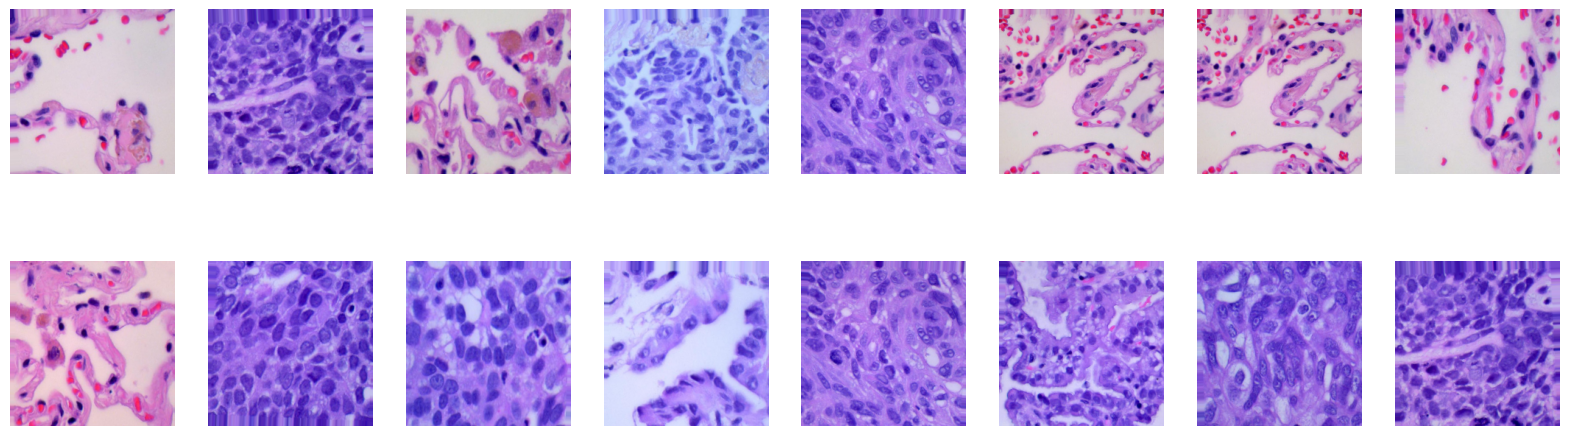

In [5]:
x,y=next(training_generator)

# Visualización de imágenes

plt.figure(1, figsize=(20,6))
plt.tight_layout()
for i in range(8):
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+1)
    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
    j = randint(0, x.shape[0]-1)
    plt.subplot(2, 8, i+9)
    plt.imshow(x[j,:,:,:].astype(np.uint8), cmap='gray')
    plt.axis("off")
plt.show()

## Tercer modelo. **MobileNetV2**

In [7]:
base_model_3 = MobileNetV2(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False,
    pooling="avg"
)

base_model_3.trainable = False

input_3 = tf.keras.layers.Input(shape=(224, 224, 3))

x3 = preprocess_mobile(input_3)
x3 = base_model_3(x3)
x3 = keras.layers.Dropout(0.2)(x3)
x3 = keras.layers.Dense(256, activation='relu')(x3)
x3 = keras.layers.BatchNormalization()(x3)
x3 = keras.layers.Dense(64, activation='relu')(x3)
x3 = keras.layers.BatchNormalization()(x3)
output_3 = keras.layers.Dense(3, activation='softmax')(x3)

model_3 = Model(inputs=input_3, outputs=output_3)

model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])


print(model_3.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,843 (9.93 MB)

 Trainable params: 345,219 (1.32 MB)

 Non-trainable params: 2,258,624 (8.62 MB)

None


In [8]:
class BarreraExactitud(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.96:
            print(f"\n✅ ¡Objetivo alcanzado! Exactitud del {logs.get('val_accuracy'):.4f}.")
            print("Deteniendo el entrenamiento...")
            self.model.stop_training = True

barrera_96 = BarreraExactitud()

history_3 = model_3.fit(
    x=training_generator,
    batch_size=32,
    epochs=15,
    verbose=1,
    validation_data=val_generator,
    shuffle=True,
    callbacks=[barrera_96]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 985s 2s/step - accuracy: 0.8063 - loss: 0.4679 - val_accuracy: 0.9564 - val_loss: 0.1254
Epoch 2/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9432 - loss: 0.1583
✅ ¡Objetivo alcanzado! Exactitud del 0.9658.
Deteniendo el entrenamiento...
399/399 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.9432 - loss: 0.1583 - val_accuracy: 0.9658 - val_loss: 0.0940


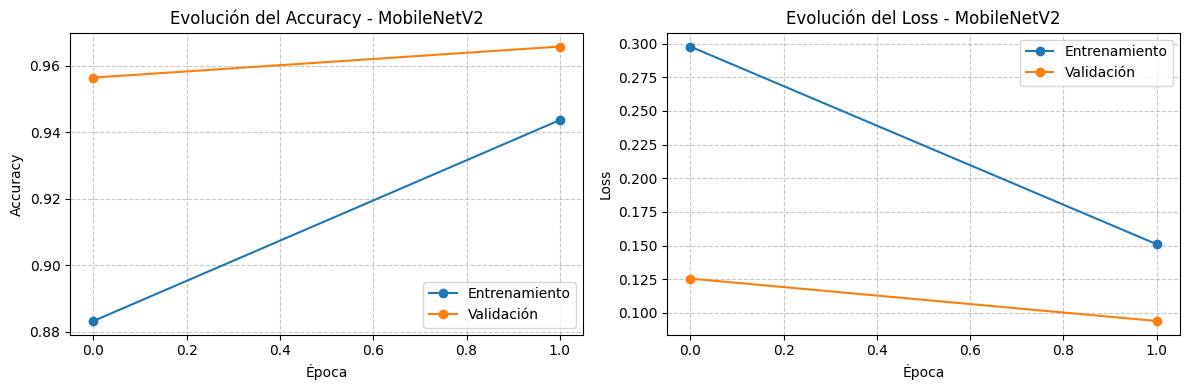

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Entrenamiento', marker='o')
plt.plot(history_3.history['val_accuracy'], label='Validación', marker='o')
plt.title('Evolución del Accuracy - MobileNetV2')
plt.ylabel('Accuracy')
plt.xlabel('Época')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Entrenamiento', marker='o')
plt.plot(history_3.history['val_loss'], label='Validación', marker='o')
plt.title('Evolución del Loss - MobileNetV2')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Evaluación del tercer modelo**

71/71 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step


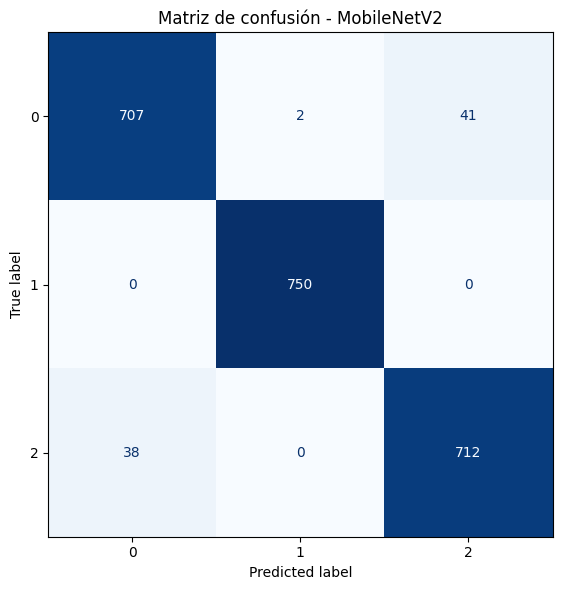


Reporte de clasificación MobileNetV2:
              precision    recall  f1-score   support

           0     0.9490    0.9427    0.9458       750
           1     0.9973    1.0000    0.9987       750
           2     0.9456    0.9493    0.9474       750

    accuracy                         0.9640      2250
   macro avg     0.9640    0.9640    0.9640      2250
weighted avg     0.9640    0.9640    0.9640      2250



In [10]:
# Predicciones
val_generator.reset()

y_pred_probs_3 = model_3.predict(val_generator, verbose=1)
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)
y_true = val_generator.classes

# Matriz de confusión
cm_3 = confusion_matrix(y_true, y_pred_3, labels=np.arange(3))
disp_3 = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=np.arange(3))
fig, ax = plt.subplots(figsize=(6, 6))
disp_3.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusión - MobileNetV2")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación MobileNetV2:")
print(classification_report(y_true, y_pred_3, digits=4))